In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:/Users/hp/Documents/Class/ML/Datasets/DataSet_regression.csv')
df

,Outlook,Temp,Humidity,Windy,Hours Played
0,Rainy,Hot,High,False,25
1,Rainy,Hot,High,True,30
2,Overcast,Hot,High,False,46
3,Sunny,Mild,High,False,45
4,Sunny,Cool,Normal,False,52
5,Sunny,Cool,Normal,True,23
6,Overcast,Cool,Normal,True,43
7,Rainy,Mild,High,False,35
8,Rainy,Cool,Normal,False,38
9,Sunny,Mild,Normal,False,46


In [3]:
from sklearn.preprocessing import LabelEncoder

In [4]:
le_out = LabelEncoder()
le_temp= LabelEncoder()
le_hum = LabelEncoder()
le_win = LabelEncoder()

In [5]:
df['Outlook'] = le_out.fit_transform(df['Outlook'])
df['Temp'] = le_temp.fit_transform(df['Temp'])
df['Humidity'] = le_hum.fit_transform(df['Humidity'])
df['Windy'] = le_win.fit_transform(df['Windy'])

In [6]:
df

,Outlook,Temp,Humidity,Windy,Hours Played
0,1,1,0,0,25
1,1,1,0,1,30
2,0,1,0,0,46
3,2,2,0,0,45
4,2,0,1,0,52
5,2,0,1,1,23
6,0,0,1,1,43
7,1,2,0,0,35
8,1,0,1,0,38
9,2,2,1,0,46


In [7]:
x = df.drop('Hours Played', axis=1)
x

,Outlook,Temp,Humidity,Windy
0,1,1,0,0
1,1,1,0,1
2,0,1,0,0
3,2,2,0,0
4,2,0,1,0
5,2,0,1,1
6,0,0,1,1
7,1,2,0,0
8,1,0,1,0
9,2,2,1,0


In [8]:
y = df['Hours Played']
y

0     25
1     30
2     46
3     45
4     52
5     23
6     43
7     35
8     38
9     46
10    48
11    52
12    44
13    30
Name: Hours Played, dtype: int64

In [9]:
from sklearn.tree import DecisionTreeRegressor

In [10]:
model = DecisionTreeRegressor()

In [11]:
model.fit(x,y)

DecisionTreeRegressor()

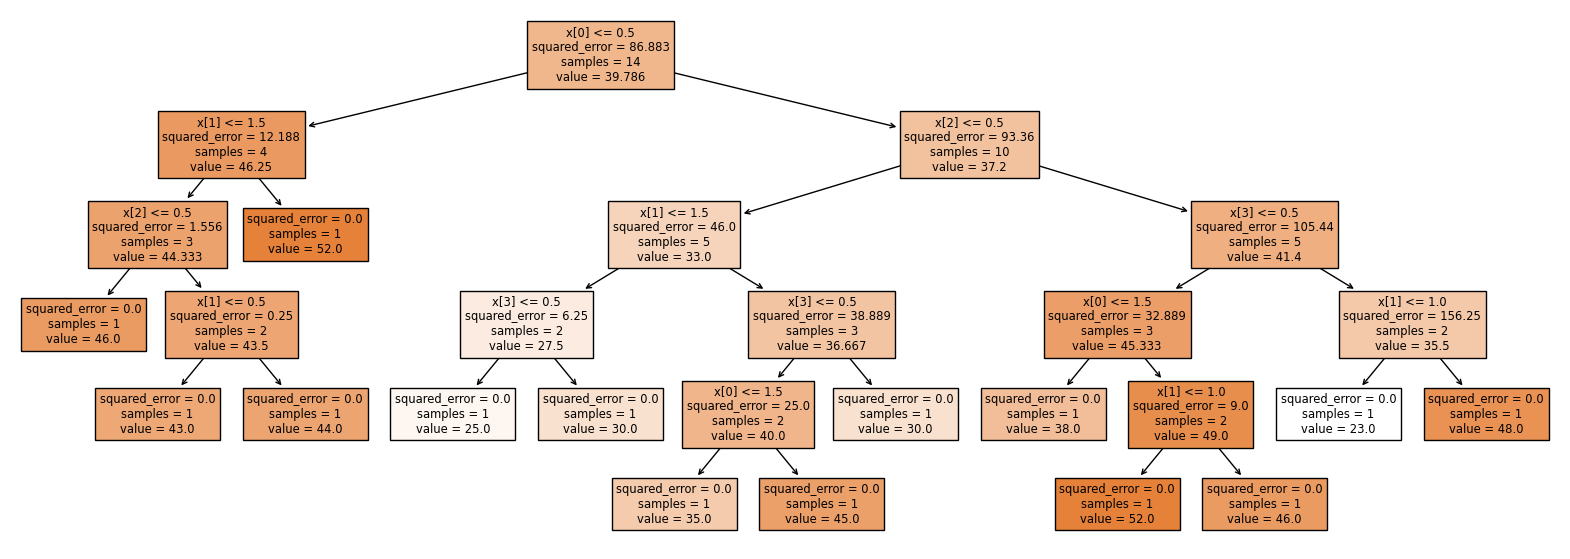

In [12]:
from sklearn import tree

plt.figure(figsize=(20,7))
tree.plot_tree(model, filled=True)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [15]:
model = DecisionTreeRegressor()

In [16]:
model.fit(x_train, y_train)

DecisionTreeRegressor()

In [17]:
y_pred = model.predict(x_test)
y_pred

array([25., 44., 23., 30., 44.])

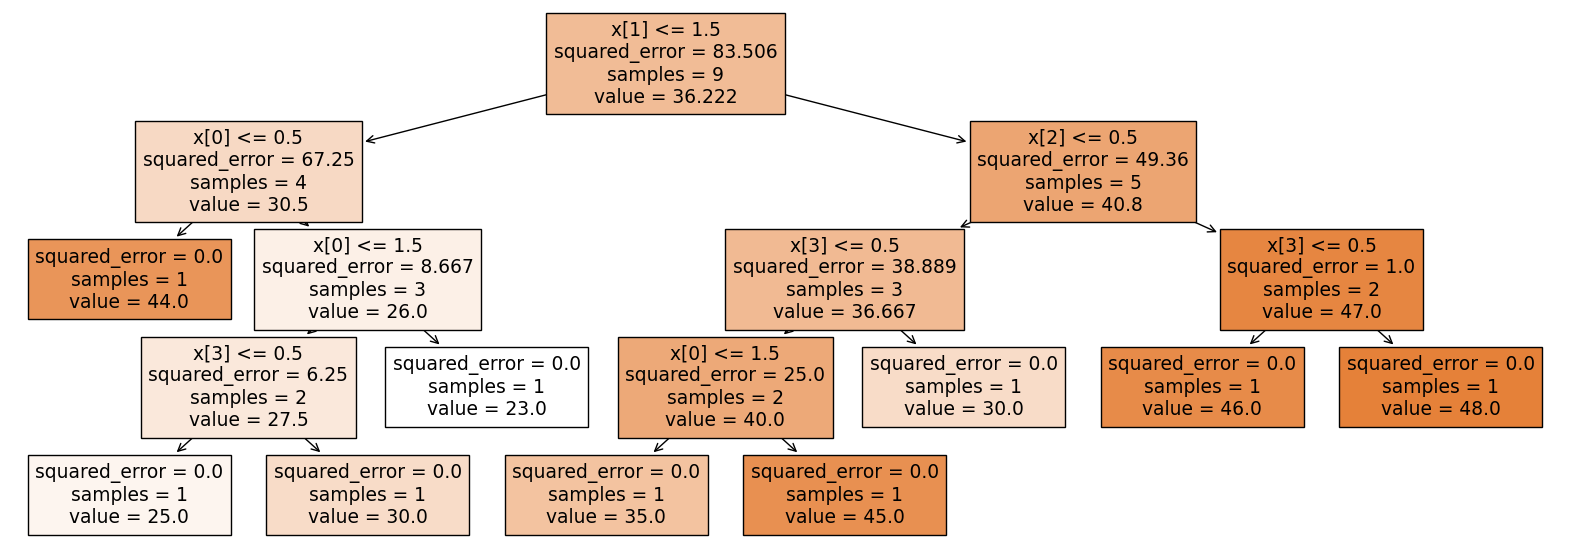

In [18]:
plt.figure(figsize=(20,7))
tree.plot_tree(model, filled=True)
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [20]:
MAE = mean_absolute_error(y_test, y_pred)
MAE

13.4

In [21]:
MSE = mean_squared_error(y_test, y_pred)
MSE

299.8

In [22]:
RMSE = np.sqrt(MSE)
RMSE

17.314733610425545

In [23]:
import pickle

In [24]:
with open('decision_re.pkl', 'wb') as file:
    pickle.dump(model, file)